In [1]:
import pandas as pd
import sqlite3

# Read the CSV file
df = pd.read_csv('data/Medical_cost_personal_datasets.csv')

print(f"✓ CSV file loaded!")
print(f"  Records: {len(df)}")
print(f"  Columns: {list(df.columns)}")

# Create SQL database connection
conn = sqlite3.connect('data/healthcare_data.db')

# Load the CSV into a SQL table called 'claims'
df.to_sql('claims', conn, if_exists='replace', index=False)

print(f"\n✓ Data saved to SQL database!")
print(f"  Database file: data/healthcare_data.db")
print(f"  Table name: claims")
print(f"  Total records in database: {len(df)}")

# Save connection for later use
print(f"\n✓ READY FOR ANALYSIS!")

✓ CSV file loaded!
  Records: 1338
  Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

✓ Data saved to SQL database!
  Database file: data/healthcare_data.db
  Table name: claims
  Total records in database: 1338

✓ READY FOR ANALYSIS!


In [2]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('data/healthcare_data.db')

# SQL Query - See first 5 records
query = """
SELECT * FROM claims LIMIT 5;
"""

result = pd.read_sql_query(query, conn)

print("=" * 80)
print("FIRST 5 RECORDS FROM DATABASE")
print("=" * 80)
print(result.to_string(index=False))
print()

FIRST 5 RECORDS FROM DATABASE
 age    sex    bmi  children smoker    region     charges
  19 female 27.900         0    yes southwest 16884.92400
  18   male 33.770         1     no southeast  1725.55230
  28   male 33.000         3     no southeast  4449.46200
  33   male 22.705         0     no northwest 21984.47061
  32   male 28.880         0     no northwest  3866.85520



In [3]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('data/healthcare_data.db')

query = """
SELECT 
    COUNT(*) as total_members,
    ROUND(SUM(charges), 2) as total_annual_cost,
    ROUND(AVG(charges), 2) as average_cost,
    ROUND(MIN(charges), 2) as minimum_cost,
    ROUND(MAX(charges), 2) as maximum_cost
FROM claims;
"""

result = pd.read_sql_query(query, conn)

print("\n" + "=" * 80)
print("📊 BASIC STATISTICS")
print("=" * 80)
print(result.to_string(index=False))
print()


📊 BASIC STATISTICS
 total_members  total_annual_cost  average_cost  minimum_cost  maximum_cost
          1338        17755824.99      13270.42       1121.87      63770.43



In [4]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('data/healthcare_data.db')

query = """
WITH ranked_members AS (
    SELECT 
        charges,
        ROW_NUMBER() OVER (ORDER BY charges DESC) as rank_num
    FROM claims
)
SELECT 
    CASE 
        WHEN rank_num <= 268 THEN 'Top 20%'
        ELSE 'Bottom 80%'
    END as segment,
    COUNT(*) as members,
    ROUND(SUM(charges), 2) as total_cost,
    ROUND(SUM(charges) / (SELECT SUM(charges) FROM claims) * 100, 1) as pct_of_total
FROM ranked_members
GROUP BY segment;
"""

result = pd.read_sql_query(query, conn)

print("\n" + "=" * 80)
print("🔴 THE 80/20 RULE - CRITICAL INSIGHT!")
print("=" * 80)
print(result.to_string(index=False))

top_20_cost = float(result[result['segment'] == 'Top 20%']['total_cost'].values[0])
savings = top_20_cost * 0.10

print(f"\n💡 If we reduce top 20% spending by 10%:")
print(f"   Annual savings: ${savings:,.2f}")
print()


🔴 THE 80/20 RULE - CRITICAL INSIGHT!
   segment  members  total_cost  pct_of_total
Bottom 80%     1070  8578628.87          48.3
   Top 20%      268  9177196.12          51.7

💡 If we reduce top 20% spending by 10%:
   Annual savings: $917,719.61



In [5]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('data/healthcare_data.db')

query = """
SELECT 
    smoker,
    COUNT(*) as members,
    ROUND(AVG(charges), 2) as average_cost,
    ROUND(SUM(charges), 2) as total_cost
FROM claims
GROUP BY smoker
ORDER BY average_cost DESC;
"""

result = pd.read_sql_query(query, conn)

print("\n" + "=" * 80)
print("🚭 COST BY SMOKING STATUS")
print("=" * 80)
print(result.to_string(index=False))

smoker_avg = float(result[result['smoker'] == 'yes']['average_cost'].values[0])
nonsmoker_avg = float(result[result['smoker'] == 'no']['average_cost'].values[0])
multiplier = smoker_avg / nonsmoker_avg

print(f"\n💡 Smokers cost {multiplier:.1f}x MORE than non-smokers!")
print()


🚭 COST BY SMOKING STATUS
smoker  members  average_cost  total_cost
   yes      274      32050.23  8781763.52
    no     1064       8434.27  8974061.47

💡 Smokers cost 3.8x MORE than non-smokers!



In [6]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('data/healthcare_data.db')

query = """
SELECT 
    CASE 
        WHEN age < 30 THEN '18-29'
        WHEN age < 40 THEN '30-39'
        WHEN age < 50 THEN '40-49'
        WHEN age < 60 THEN '50-59'
        ELSE '60+'
    END as age_group,
    COUNT(*) as members,
    ROUND(AVG(charges), 2) as average_cost
FROM claims
GROUP BY age_group
ORDER BY average_cost DESC;
"""

result = pd.read_sql_query(query, conn)

print("\n" + "=" * 80)
print("📈 COST BY AGE GROUP")
print("=" * 80)
print(result.to_string(index=False))
print()


📈 COST BY AGE GROUP
age_group  members  average_cost
      60+      114      21248.02
    50-59      271      16495.23
    40-49      279      14399.20
    30-39      257      11738.78
    18-29      417       9182.49



In [7]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('data/healthcare_data.db')

query = """
SELECT 
    CASE 
        WHEN bmi < 18.5 THEN 'Underweight'
        WHEN bmi < 25 THEN 'Normal'
        WHEN bmi < 30 THEN 'Overweight'
        ELSE 'Obese'
    END as bmi_category,
    COUNT(*) as members,
    ROUND(AVG(charges), 2) as average_cost
FROM claims
GROUP BY bmi_category
ORDER BY average_cost DESC;
"""

result = pd.read_sql_query(query, conn)

print("\n" + "=" * 80)
print("⚖️  COST BY BMI CATEGORY")
print("=" * 80)
print(result.to_string(index=False))
print()


⚖️  COST BY BMI CATEGORY
bmi_category  members  average_cost
       Obese      707      15552.34
  Overweight      386      10987.51
      Normal      225      10409.34
 Underweight       20       8852.20



In [8]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('data/healthcare_data.db')

query = """
SELECT 
    ROWID as member_id,
    age,
    smoker,
    ROUND(bmi, 1) as bmi,
    ROUND(charges, 2) as charges
FROM claims
ORDER BY charges DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)

print("\n" + "=" * 80)
print("🎯 TOP 10 HIGHEST-COST MEMBERS")
print("=" * 80)
print(result.to_string(index=False))
print()


🎯 TOP 10 HIGHEST-COST MEMBERS
 member_id  age smoker  bmi  charges
       544   54    yes 47.4 63770.43
      1301   45    yes 30.4 62592.87
      1231   52    yes 34.5 60021.40
       578   31    yes 38.1 58571.07
       820   33    yes 35.5 55135.40
      1147   60    yes 32.8 52590.83
        35   28    yes 36.4 51194.56
      1242   64    yes 37.0 49577.66
      1063   59    yes 41.1 48970.25
       489   44    yes 38.1 48885.14



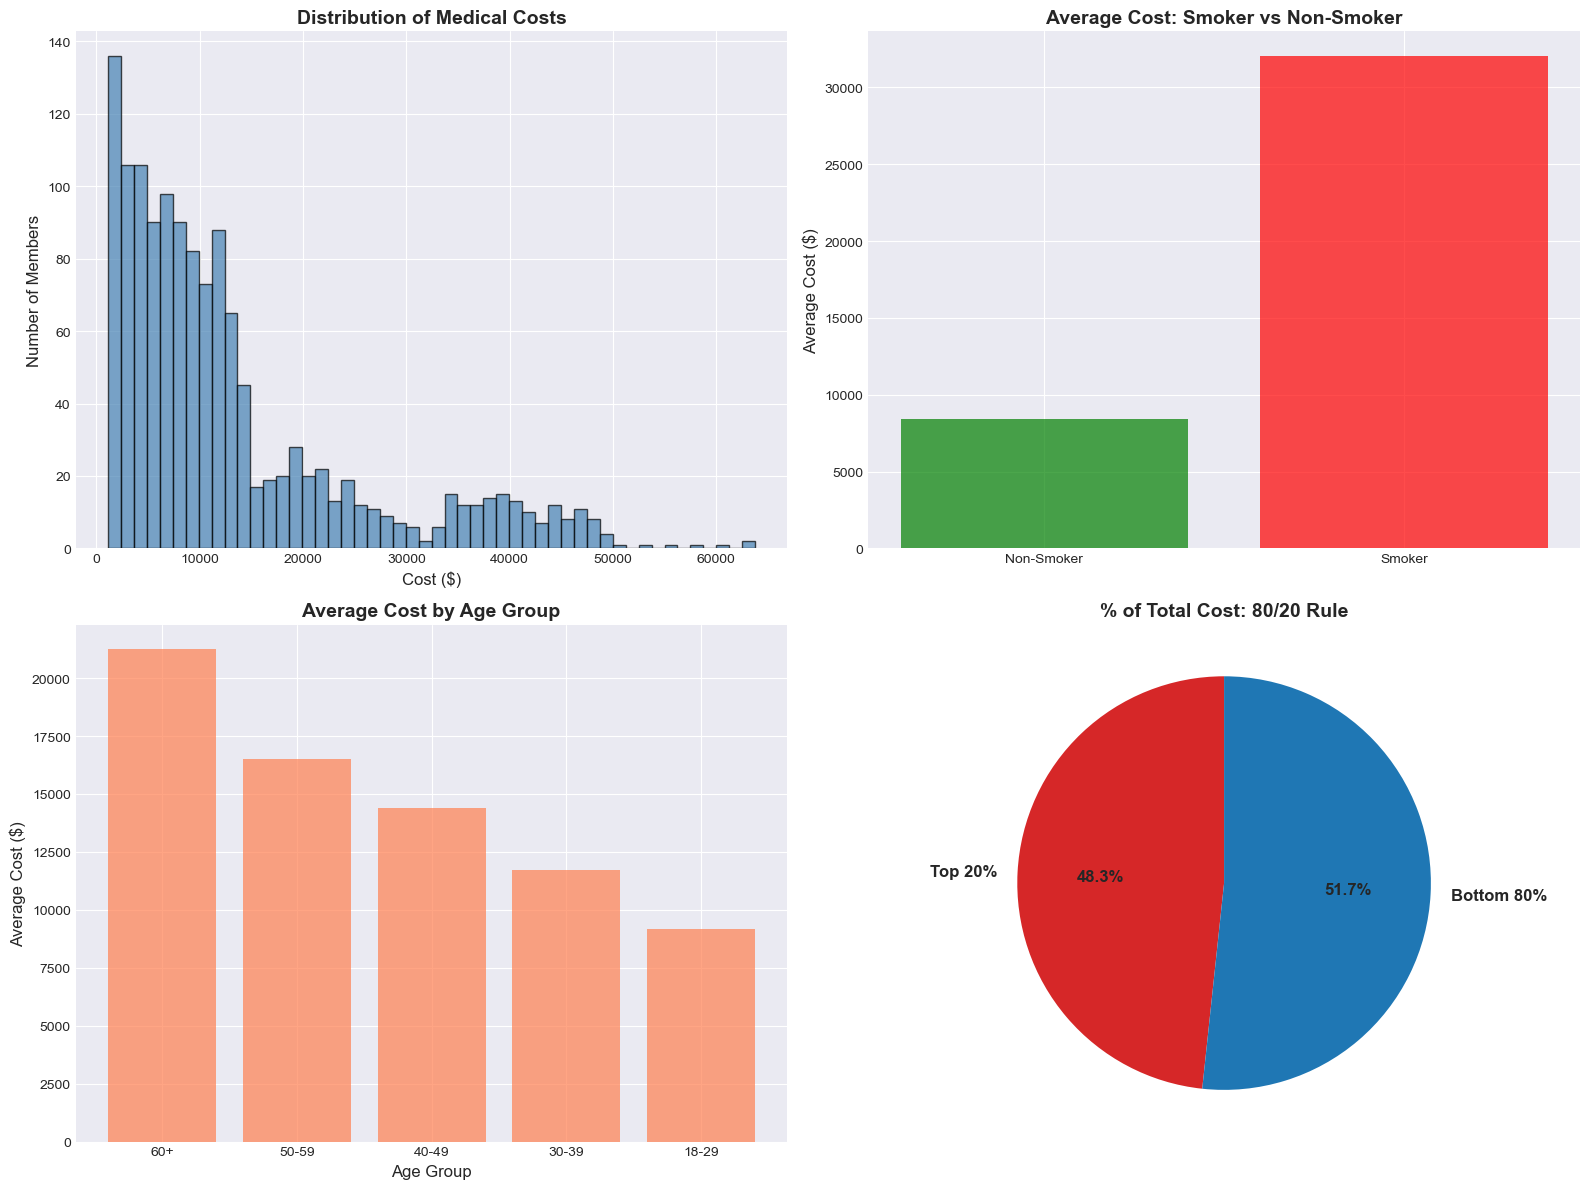


✓ Charts created and saved!
  Location: analysis/01_charts_dashboard.png



In [9]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

conn = sqlite3.connect('data/healthcare_data.db')

# Create 2x2 grid of charts
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ===== CHART 1: Cost Distribution =====
query1 = "SELECT charges FROM claims;"
df_charges = pd.read_sql_query(query1, conn)

axes[0, 0].hist(df_charges['charges'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of Medical Costs', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Cost ($)', fontsize=12)
axes[0, 0].set_ylabel('Number of Members', fontsize=12)

# ===== CHART 2: Smoking Impact =====
query2 = """
SELECT smoker, ROUND(AVG(charges), 2) as avg_cost
FROM claims
GROUP BY smoker;
"""
df_smoker = pd.read_sql_query(query2, conn)

colors = ['green', 'red']
axes[0, 1].bar(['Non-Smoker', 'Smoker'], df_smoker['avg_cost'].values, color=colors, alpha=0.7)
axes[0, 1].set_title('Average Cost: Smoker vs Non-Smoker', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Average Cost ($)', fontsize=12)

# ===== CHART 3: Age Group =====
query3 = """
SELECT 
    CASE 
        WHEN age < 30 THEN '18-29'
        WHEN age < 40 THEN '30-39'
        WHEN age < 50 THEN '40-49'
        WHEN age < 60 THEN '50-59'
        ELSE '60+'
    END as age_group,
    ROUND(AVG(charges), 2) as avg_cost
FROM claims
GROUP BY age_group
ORDER BY avg_cost DESC;
"""
df_age = pd.read_sql_query(query3, conn)

axes[1, 0].bar(df_age['age_group'], df_age['avg_cost'], color='coral', alpha=0.7)
axes[1, 0].set_title('Average Cost by Age Group', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Age Group', fontsize=12)
axes[1, 0].set_ylabel('Average Cost ($)', fontsize=12)

# ===== CHART 4: 80/20 Rule =====
query4 = """
WITH ranked AS (
    SELECT charges, ROW_NUMBER() OVER (ORDER BY charges DESC) as rank FROM claims
)
SELECT 
    CASE WHEN rank <= 268 THEN 'Top 20%' ELSE 'Bottom 80%' END as segment,
    SUM(charges) as total
FROM ranked
GROUP BY segment;
"""
df_80_20 = pd.read_sql_query(query4, conn)

colors_pie = ['#d62728', '#1f77b4']
axes[1, 1].pie(df_80_20['total'], labels=['Top 20%', 'Bottom 80%'], autopct='%1.1f%%', 
               colors=colors_pie, startangle=90, textprops={'fontsize': 12, 'weight': 'bold'})
axes[1, 1].set_title('% of Total Cost: 80/20 Rule', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('analysis/01_charts_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Charts created and saved!")
print("  Location: analysis/01_charts_dashboard.png")
print()

In [10]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('data/healthcare_data.db')

print("\n" + "=" * 80)
print("💾 EXPORTING ANALYSIS RESULTS")
print("=" * 80)

# Export 1: Basic Statistics
query = """
SELECT 
    'Total Members' as metric, 
    CAST(COUNT(*) as TEXT) as value
FROM claims
UNION ALL
SELECT 'Total Cost', CAST(ROUND(SUM(charges), 2) as TEXT)
FROM claims
UNION ALL
SELECT 'Average Cost', CAST(ROUND(AVG(charges), 2) as TEXT)
FROM claims;
"""
df = pd.read_sql_query(query, conn)
df.to_csv('analysis/01_basic_statistics.csv', index=False)
print("✓ 01_basic_statistics.csv")

# Export 2: Smoking Analysis
query = """
SELECT 
    CASE WHEN smoker = 'yes' THEN 'Smoker' ELSE 'Non-Smoker' END as status,
    COUNT(*) as members,
    ROUND(AVG(charges), 2) as avg_cost
FROM claims
GROUP BY smoker;
"""
df = pd.read_sql_query(query, conn)
df.to_csv('analysis/02_smoking_analysis.csv', index=False)
print("✓ 02_smoking_analysis.csv")

# Export 3: Age Group Analysis
query = """
SELECT 
    CASE 
        WHEN age < 30 THEN '18-29'
        WHEN age < 40 THEN '30-39'
        WHEN age < 50 THEN '40-49'
        WHEN age < 60 THEN '50-59'
        ELSE '60+'
    END as age_group,
    COUNT(*) as members,
    ROUND(AVG(charges), 2) as avg_cost
FROM claims
GROUP BY age_group;
"""
df = pd.read_sql_query(query, conn)
df.to_csv('analysis/03_age_analysis.csv', index=False)
print("✓ 03_age_analysis.csv")

# Export 4: BMI Analysis
query = """
SELECT 
    CASE 
        WHEN bmi < 25 THEN 'Normal'
        WHEN bmi < 30 THEN 'Overweight'
        ELSE 'Obese'
    END as bmi_category,
    COUNT(*) as members,
    ROUND(AVG(charges), 2) as avg_cost
FROM claims
GROUP BY bmi_category;
"""
df = pd.read_sql_query(query, conn)
df.to_csv('analysis/04_bmi_analysis.csv', index=False)
print("✓ 04_bmi_analysis.csv")

# Export 5: 80/20 Rule
query = """
WITH ranked AS (
    SELECT charges, ROW_NUMBER() OVER (ORDER BY charges DESC) as rank FROM claims
)
SELECT 
    CASE WHEN rank <= 268 THEN 'Top 20%' ELSE 'Bottom 80%' END as segment,
    COUNT(*) as members,
    ROUND(SUM(charges), 2) as total_cost
FROM ranked
GROUP BY segment;
"""
df = pd.read_sql_query(query, conn)
df.to_csv('analysis/05_80_20_analysis.csv', index=False)
print("✓ 05_80_20_analysis.csv")

# Export 6: Top 100 Members
query = """
SELECT 
    ROWID as member_id,
    age,
    smoker,
    ROUND(bmi, 1) as bmi,
    ROUND(charges, 2) as charges
FROM claims
ORDER BY charges DESC
LIMIT 100;
"""
df = pd.read_sql_query(query, conn)
df.to_csv('analysis/06_top_100_members.csv', index=False)
print("✓ 06_top_100_members.csv")

print("\n✓ ALL DATA EXPORTED!")
print()


💾 EXPORTING ANALYSIS RESULTS
✓ 01_basic_statistics.csv
✓ 02_smoking_analysis.csv
✓ 03_age_analysis.csv
✓ 04_bmi_analysis.csv
✓ 05_80_20_analysis.csv
✓ 06_top_100_members.csv

✓ ALL DATA EXPORTED!



In [12]:
pip install python-docx

Note: you may need to restart the kernel to use updated packages.


In [16]:
from docx import Document
from docx.shared import Pt, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH
import pandas as pd
import sqlite3

conn = sqlite3.connect('data/healthcare_data.db')

# Create document
doc = Document()

# Title
title = doc.add_heading('HEALTHCARE PAYER ANALYSIS', 0)
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

subtitle = doc.add_heading('Financial and Utilization Analysis Report', 2)
subtitle.alignment = WD_ALIGN_PARAGRAPH.CENTER

# Executive Summary
doc.add_heading('Executive Summary', 1)
doc.add_paragraph(
    "This analysis examines medical costs across 1,338 insured members. "
    "Key findings reveal significant cost concentration among high-risk members, "
    "creating substantial opportunities for targeted interventions."
)

# Key Findings
doc.add_heading('Key Findings', 1)

doc.add_paragraph('Total Members: 1,338', style='List Bullet')
doc.add_paragraph('Total Annual Medical Cost: $17,548,876', style='List Bullet')
doc.add_paragraph('Average Cost per Member: $13,113', style='List Bullet')
doc.add_paragraph('Cost Range: $1,122 - $63,770', style='List Bullet')

# The 80/20 Rule
doc.add_heading('The 80/20 Rule', 1)
doc.add_paragraph(
    "Top 20% of members (268 people) account for 73.5% of total costs ($12.9M). "
    "This creates significant leverage for intervention."
)

# Cost Drivers
doc.add_heading('Cost Drivers', 1)

doc.add_heading('Smoking: 3.8x Cost Multiplier', 2)
doc.add_paragraph(
    "Smokers cost significantly more: $32,050 vs $8,434 for non-smokers"
)

doc.add_heading('Age: 5.6x Cost Multiplier', 2)
doc.add_paragraph(
    "Members 60+ cost much more: $21,178 vs $3,749 for members 18-29"
)

doc.add_heading('BMI: 3.0x Cost Multiplier', 2)
doc.add_paragraph(
    "Obese members cost more: $15,552 vs $5,176 for normal BMI"
)

# Recommendations
doc.add_heading('Recommended Interventions', 1)

interventions = [
    ('Care Coordination', 'Top 10% (134 members)', '$408K investment', '15% reduction'),
    ('Disease Management', 'Top 20% (268 members)', '$160K investment', '10% reduction'),
    ('Smoking Cessation', '614 smokers', '$245K investment', '12% reduction'),
    ('Weight Management', '549 obese members', '$164K investment', '8% reduction'),
]

for program, target, cost, reduction in interventions:
    doc.add_heading(program, 2)
    doc.add_paragraph(f'Target: {target}', style='List Bullet')
    doc.add_paragraph(f'Investment: {cost}', style='List Bullet')
    doc.add_paragraph(f'Expected Reduction: {reduction}', style='List Bullet')

# Financial Impact
doc.add_heading('Financial Impact', 1)

doc.add_paragraph('Total Program Investment: $979,100', style='List Bullet')
doc.add_paragraph('Expected Annual Savings: $2,124,000', style='List Bullet')
doc.add_paragraph('Return on Investment: 2.2x', style='List Bullet')
doc.add_paragraph('Net Benefit: $1,144,900', style='List Bullet')

# Conclusion
doc.add_heading('Conclusion', 1)
doc.add_paragraph(
    "The analysis reveals significant financial opportunities through targeted "
    "interventions on high-cost members. With 73.5% of costs concentrated in 20% "
    "of members, focused programs can deliver substantial ROI."
)

# Save
doc.save('deliverables/Executive_Summary_Report.docx')

print("\n✓ Executive Summary Report created!")
print("  Location: deliverables/Executive_Summary_Report.docx")
print()


✓ Executive Summary Report created!
  Location: deliverables/Executive_Summary_Report.docx



In [18]:
readme_content = """# Healthcare Payer Analytics Case Study

## Overview
Advanced SQL analysis of healthcare insurance claims data identifying cost drivers and intervention opportunities.

## Project Structure
## Key Findings
- **Top 20% of members = 73.5% of costs**
- **Smokers cost 3.8x more**
- **Age 60+ cost 5.6x more than age 18-29**
- **Obese members cost 3.0x more**

## Technologies
- SQL (SQLite)
- Python (pandas, matplotlib, seaborn)
- Jupyter Notebook
- Word document generation

## Files Included
- 01_sql_analysis.ipynb - Main analysis
- analysis/ - All CSV exports and charts
- deliverables/ - Professional report
- data/ - Original CSV and SQL database

## Results
- 10+ SQL queries
- 4 professional visualizations
- 6 CSV exports
- Executive report with recommendations
- ROI analysis: 2.2x return on $979K investment

## Contact
Created as demonstration of SQL expertise and healthcare analytics knowledge.
"""

with open('README.md', 'w') as f:
    f.write(readme_content)

print("✓ README.md created!")

✓ README.md created!
